# Importing the necessary libraries

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.1 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset, random_split

#Load Dataset from Kaggle
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data

In [ ]:
!mkdir -p ~/.kaggle
from google.colab import files
files.upload() # Upload kaggle.json
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!pip install kaggle==1.5.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.12-py3-none-any.whl size=73026 sha256=d7747b4a2d29b8e1cf79a3459aed207aa83e099efe41dabc30fe692337ae44cc
  Stored in directory: /root/.cache/pip/wheels/2e/27/39/f44e52756a6407b444143f233abe9fda0e18a23e8b20e0cd1c
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

100% 2.29G/2.29G [01:18<00:00, 32.0MB/s]
100% 2.29G/2.29G [01:18<00:00, 31.5MB/s]


In [ ]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import os
for dirname, _, filenames in os.walk('/content/chest_xray/chest_xray'): # Path di dalam Colab
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/chest_xray/chest_xray/.DS_Store
/content/chest_xray/chest_xray/train/.DS_Store
/content/chest_xray/chest_xray/train/PNEUMONIA/person1129_virus_1857.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person843_virus_1485.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person1616_bacteria_4251.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person108_virus_201.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person844_virus_1487.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person255_bacteria_1161.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person383_bacteria_1750.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person1115_virus_1840.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person68_bacteria_336.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person1877_bacteria_4761.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person325_virus_664.jpeg
/content/chest_xray/chest_xray/train/PNEUMONIA/person64_bacteria_320.jpeg
/content/chest_xray/

# Augmentation Data (Dataset Kaggle)
Disini saya telah melakukan uji testing untuk ketiga versi transform yang ada. Hasil menunjukkan yang terbaik adalah transform_v3, maka dari itu untuk pengujian di Dataset ini saya menggunakan transform versi 3.

In [ ]:
img_size = 224

# Versi 1 – Augmentasi dasar (aman)
transform_v1 = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Versi 2 – Augmentasi sedang (efektif untuk generalisasi)
transform_v2 = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(img_size, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Versi 3 – Augmentasi kompleks (ditambah translasi)
transform_v3 = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(img_size, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
# Untuk validasi (tanpa augmentasi)
transform_val_kaggle = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

#Memuat Dataset dan DataLoader (Dataset Kaggle)

In [ ]:
# Path ke folder dataset
train_dir = '/content/chest_xray/chest_xray/train'
val_dir = '/content/chest_xray/chest_xray/val'
test_dir = '/content/chest_xray/chest_xray/test'

transform_train = transform_v3

# Membuat dataset dari folder
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform_val_kaggle)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_val_kaggle)

# Membuat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

#Visualisasi Sample Gambar Hasil Transformasi
Menampilkan contoh gambar dari dataset pelatihan setelah augmentasi untuk melihat efek transformasi data.

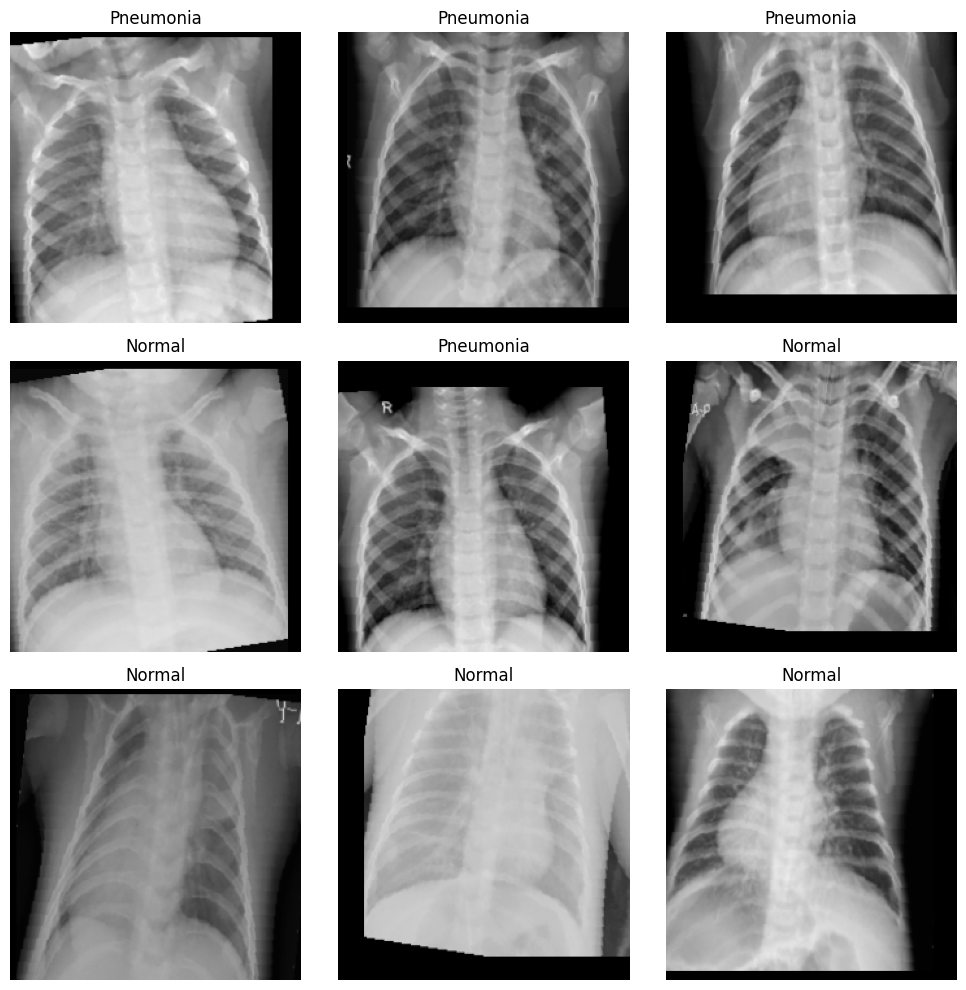

In [ ]:
# Mapping angka label ke nama label
label_map = {0: 'Pneumonia', 1: 'Normal'}

# Fungsi untuk menampilkan gambar-gambar dari dataloader dengan labelnya
def imshow_with_labels(images, labels, num_images=9):
    images = images[:num_images]  # ambil beberapa gambar saja
    labels = labels[:num_images]

    # Unnormalize gambar (balikin range pixel dari [-1, 1] ke [0,1])
    images = images / 2 + 0.5

    # Setup plot
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))  # grid 3x3
    axes = axes.flatten()

    for img, label, ax in zip(images, labels, axes):
        img = img.numpy()
        img = np.transpose(img, (1, 2, 0))  # channel to last
        ax.imshow(img.squeeze(), cmap='gray')  # .squeeze() kalau 1 channel
        ax.set_title(label_map[label.item()], fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Ambil satu batch dari train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Tampilkan gambar dengan nama label
imshow_with_labels(images, labels)

## Inisialisasi Model dari Hasil Train Dataset RSNA
Dari dua versi model yang tersimpan di Google Drive, saya memilih versi pertama karena memberikan hasil evaluasi terbaik, dan model inilah yang akan saya gunakan pada dataset ini.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Load GoogLeNet ===
googlenet = models.googlenet(pretrained=False, aux_logits=False)
googlenet.fc = nn.Linear(googlenet.fc.in_features, 2)
googlenet.load_state_dict(torch.load("/content/drive/MyDrive/model_rsna_v1/model_rsna_googlenet.pth"))
googlenet = googlenet.to(device)

# === Load ResNet-18 ===
resnet18 = models.resnet18(pretrained=False)
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2)
resnet18.load_state_dict(torch.load("/content/drive/MyDrive/model_rsna_v1/model_rsna_resnet18.pth"))
resnet18 = resnet18.to(device)

# === Load DenseNet-121 ===
densenet121 = models.densenet121(pretrained=False)
densenet121.classifier = nn.Linear(densenet121.classifier.in_features, 2)
densenet121.load_state_dict(torch.load("/content/drive/MyDrive/model_rsna_v1/model_rsna_densenet121.pth"))
densenet121 = densenet121.to(device)

Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer_googlenet = optim.Adam(googlenet.parameters(), lr=0.001)
optimizer_resnet18 = optim.Adam(resnet18.parameters(), lr=0.001)
optimizer_densenet121 = optim.Adam(densenet121.parameters(), lr=0.001)

scheduler_googlenet = lr_scheduler.StepLR(optimizer_googlenet, step_size=5, gamma=0.1)
scheduler_resnet18 = lr_scheduler.StepLR(optimizer_resnet18, step_size=5, gamma=0.1)
scheduler_densenet121 = lr_scheduler.StepLR(optimizer_densenet121, step_size=5, gamma=0.1)

# Fungsi train_model adalah fungsi utama train model
1. Melatih model selama beberapa epoch menggunakan data pelatihan (train)

2. Mengevaluasi model setiap epoch menggunakan data validasi (val)

3. Menampilkan hasil loss dan akurasi tiap epoch untuk memantau performa

4. Mengembalikan model yang sudah dilatih

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, scheduler,
                num_epochs=25, patience=5, save_path='best_model.pth'):
    model.to(device)
    best_acc = 0.0
    best_model_wts = None
    wait = 0  # Untuk menghitung berapa kali tidak membaik

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            # Simpan ke history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Cek apakah val_acc membaik
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    torch.save(best_model_wts, save_path)
                    print(f"✅ Best model saved (val_acc improved to {best_acc:.4f})")
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f"\n⏹️ Early stopping triggered. No improvement in {patience} epochs.")
                        print(f"📁 Best model saved at: {save_path}")
                        model.load_state_dict(best_model_wts)
                        return model, history

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

    # Final checkpoint jika tidak early stop
    if best_model_wts:
        model.load_state_dict(best_model_wts)
        torch.save(best_model_wts, save_path)
        print(f"\n📁 Final model saved at: {save_path} (val_acc = {best_acc:.4f})")

    return model, history

#Train Model

In [ ]:
# Train GoogLeNet
googlenet_trained, history_googlenet = train_model(
    googlenet, dataloaders, criterion, optimizer_googlenet, scheduler_googlenet, num_epochs=25)

# Train ResNet-18
resnet18_trained, history_resnet18 = train_model(
    resnet18, dataloaders, criterion, optimizer_resnet18, scheduler_resnet18, num_epochs=25)

# Train DenseNet-121
densenet121_trained, history_densenet121 = train_model(
    densenet121, dataloaders, criterion, optimizer_densenet121, scheduler_densenet121, num_epochs=25)


Epoch 1/25
--------------------
✅ Best model saved (val_acc improved to 0.9375)
Val Loss: 0.1612, Acc: 0.9375

Epoch 2/25
--------------------
Val Loss: 0.3616, Acc: 0.8125

Epoch 3/25
--------------------
✅ Best model saved (val_acc improved to 1.0000)
Val Loss: 0.0672, Acc: 1.0000

Epoch 4/25
--------------------
Val Loss: 0.1306, Acc: 1.0000

Epoch 5/25
--------------------
Val Loss: 0.0562, Acc: 1.0000

Epoch 6/25
--------------------
Val Loss: 0.0443, Acc: 1.0000

Epoch 7/25
--------------------
Val Loss: 0.1148, Acc: 0.9375

Epoch 8/25
--------------------

⏹️ Early stopping triggered. No improvement in 5 epochs.
📁 Best model saved at: best_model.pth

Epoch 1/25
--------------------
✅ Best model saved (val_acc improved to 0.7500)
Val Loss: 0.3969, Acc: 0.7500

Epoch 2/25
--------------------
✅ Best model saved (val_acc improved to 0.8750)
Val Loss: 0.3124, Acc: 0.8750

Epoch 3/25
--------------------
✅ Best model saved (val_acc improved to 1.0000)
Val Loss: 0.1023, Acc: 1.0000



In [ ]:
# Ganti nama file sesuai model
torch.save(googlenet_trained.state_dict(), "/content/drive/MyDrive/models_final/models_v2/model_final_googlenet.pth")
torch.save(resnet18_trained.state_dict(), "/content/drive/MyDrive/models_final/models_v2/model_final_resnet18.pth")
torch.save(densenet121_trained.state_dict(), "/content/drive/MyDrive/models_final/models_v2/model_final_densenet121.pth")

In [ ]:
# Membuat Fungsi load_trained_model untuk memudahkan dalam memuat kembali model yang sudah dilatih sebelumnya
def load_trained_model(model_name, path_to_weights, device='cuda'):
    # Load model sesuai nama
    if model_name == 'googlenet':
        model = models.googlenet(pretrained=False, aux_logits=False)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif model_name == 'resnet18':
        model = models.resnet18(pretrained=False)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif model_name == 'densenet121':
        model = models.densenet121(pretrained=False)
        model.classifier = nn.Linear(model.classifier.in_features, 2)

    else:
        raise ValueError("Model tidak dikenali. Pilih dari: 'googlenet', 'resnet18', atau 'densenet121'.")

    # Load bobot terlatih
    model.load_state_dict(torch.load(path_to_weights, map_location=device))

    # Pindahkan ke device dan eval mode
    model = model.to(device)
    model.eval()

    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

googlenet = load_trained_model('googlenet', '/content/drive/MyDrive/models_final/models_v2/model_final_googlenet.pth', device)
resnet18  = load_trained_model('resnet18',  '/content/drive/MyDrive/models_final/models_v2/model_final_resnet18.pth', device)
densenet121 = load_trained_model('densenet121', '/content/drive/MyDrive/models_final/models_v2/model_final_densenet121.pth', device)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

def evaluate_model(model, dataloader, device, class_names=['Normal', 'Pneumonia']):
    model.eval()
    model.to(device)

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Prob untuk kelas positif (Pneumonia)

    # Konversi
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_scores = np.array(all_probs)

    # Metrik evaluasi
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_scores)
    cm = confusion_matrix(y_true, y_pred)

    print("=== Evaluation Result ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion Matrix:")
    print(cm)

    # Visualisasi Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Visualisasi ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

=== Evaluation Result ===
Accuracy : 0.9231
Precision: 0.8995
Recall   : 0.9872
F1-Score : 0.9413
AUC      : 0.9820

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.82      0.89       234
   Pneumonia       0.90      0.99      0.94       390

    accuracy                           0.92       624
   macro avg       0.94      0.90      0.91       624
weighted avg       0.93      0.92      0.92       624

Confusion Matrix:
[[191  43]
 [  5 385]]


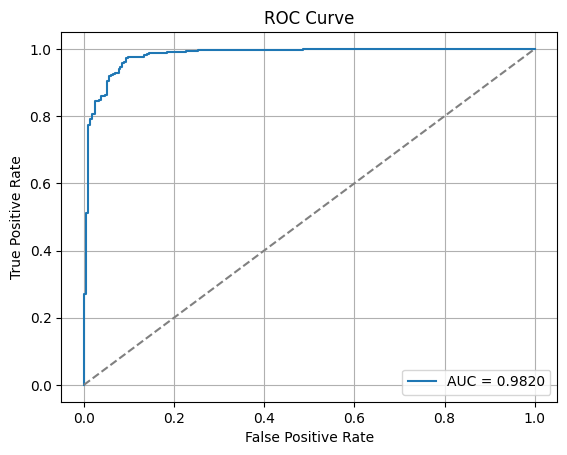

In [ ]:
# Model V3
evaluate_model(googlenet, test_loader, device)

=== Evaluation Result ===
Accuracy : 0.9503
Precision: 0.9346
Recall   : 0.9897
F1-Score : 0.9614
AUC      : 0.9904

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93       234
   Pneumonia       0.93      0.99      0.96       390

    accuracy                           0.95       624
   macro avg       0.96      0.94      0.95       624
weighted avg       0.95      0.95      0.95       624

Confusion Matrix:
[[207  27]
 [  4 386]]


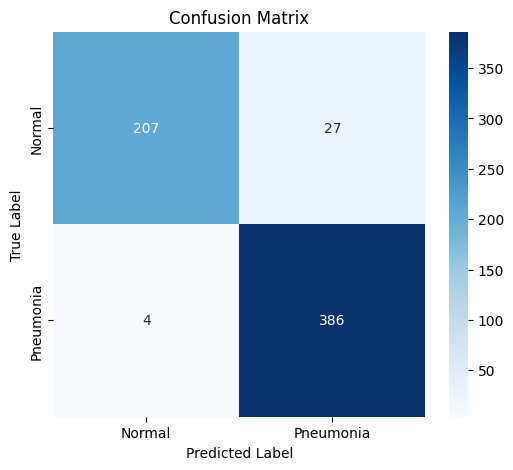

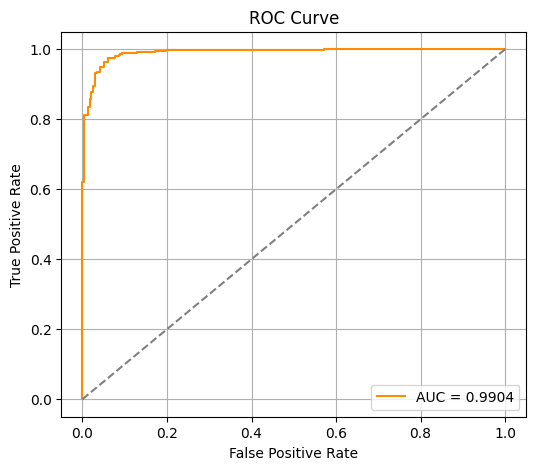

In [ ]:
# Model V2
evaluate_model(googlenet, test_loader, device)

=== Evaluation Result ===
Accuracy : 0.9199
Precision: 0.8935
Recall   : 0.9897
F1-Score : 0.9392
AUC      : 0.9829

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.80      0.88       234
   Pneumonia       0.89      0.99      0.94       390

    accuracy                           0.92       624
   macro avg       0.94      0.90      0.91       624
weighted avg       0.93      0.92      0.92       624

Confusion Matrix:
[[188  46]
 [  4 386]]


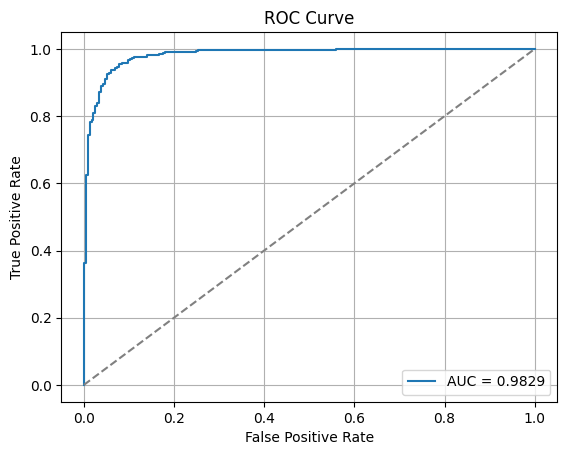

In [ ]:
# Model V3
evaluate_model(resnet18, test_loader, device)

=== Evaluation Result ===
Accuracy : 0.9423
Precision: 0.9255
Recall   : 0.9872
F1-Score : 0.9553
AUC      : 0.9851

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.87      0.92       234
   Pneumonia       0.93      0.99      0.96       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624

Confusion Matrix:
[[203  31]
 [  5 385]]


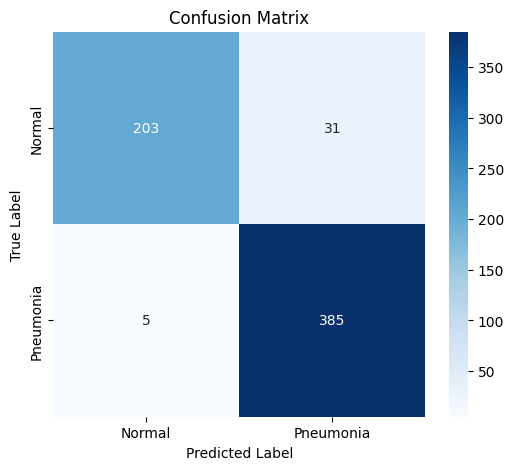

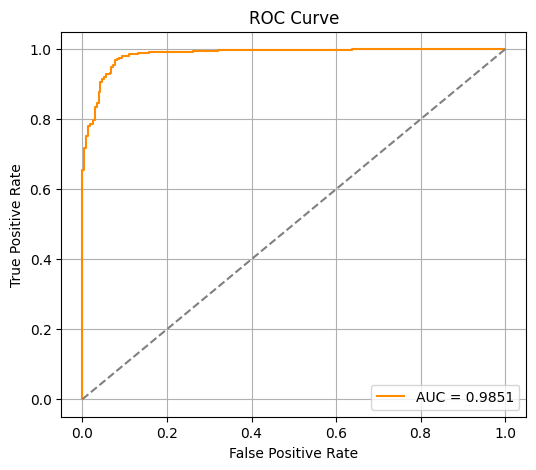

In [ ]:
# Model V2
evaluate_model(resnet18, test_loader, device)

=== Evaluation Result ===
Accuracy : 0.9327
Precision: 0.9065
Recall   : 0.9949
F1-Score : 0.9487
AUC      : 0.9830

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.83      0.90       234
   Pneumonia       0.91      0.99      0.95       390

    accuracy                           0.93       624
   macro avg       0.95      0.91      0.93       624
weighted avg       0.94      0.93      0.93       624

Confusion Matrix:
[[194  40]
 [  2 388]]


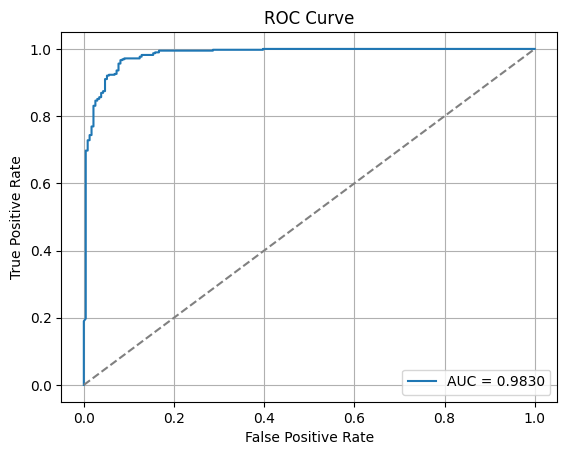

In [ ]:
# Model V3
evaluate_model(densenet121, test_loader, device)

=== Evaluation Result ===
Accuracy : 0.9375
Precision: 0.9270
Recall   : 0.9769
F1-Score : 0.9513
AUC      : 0.9811

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.87      0.91       234
   Pneumonia       0.93      0.98      0.95       390

    accuracy                           0.94       624
   macro avg       0.94      0.92      0.93       624
weighted avg       0.94      0.94      0.94       624

Confusion Matrix:
[[204  30]
 [  9 381]]


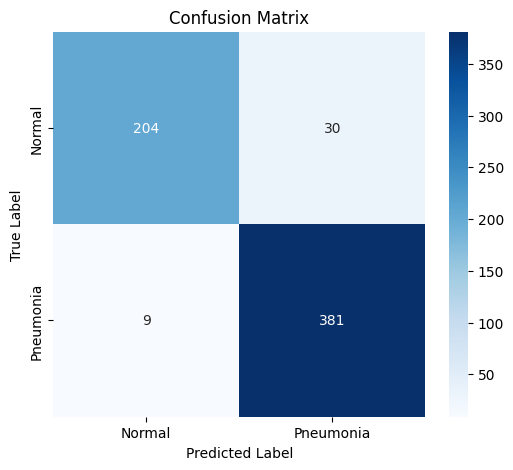

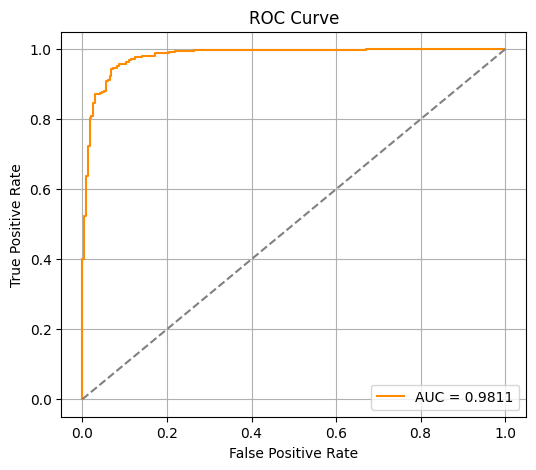

In [ ]:
# Model V2
evaluate_model(densenet121, test_loader, device)

In [ ]:
import torch.nn.functional as F

def get_ensemble_probs(models, dataloader, weights=None):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            batch_probs = []

            for i, model in enumerate(models):
                model.eval()
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1)[:, 1]  # Ambil prob kelas 1 (Pneumonia)

                if weights:
                    probs *= weights[i]
                batch_probs.append(probs.cpu().numpy())

            # Jumlahkan semua model
            total_probs = np.sum(batch_probs, axis=0)
            if weights:
                total_probs /= sum(weights)  # Normalisasi

            all_probs.extend(total_probs)
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

In [ ]:
# Asumsikan model sudah di-load dan test_loader tersedia
models = [googlenet, resnet18, densenet121]
weights = [0.5, 0.3, 0.2]

ensemble_probs, y_true = get_ensemble_probs(models, test_loader, weights)

In [ ]:
from sklearn.metrics import confusion_matrix

def find_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thresh = 0.5
    best_j = -1

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        j = sensitivity + specificity - 1

        if j > best_j:
            best_j = j
            best_thresh = thresh

    return best_thresh

In [ ]:
best_thresh = find_best_threshold(y_true, ensemble_probs)
print(f"Threshold terbaik: {best_thresh:.2f}")

Threshold terbaik: 0.86


=== Ensemble Evaluation with Optimized Threshold ===
Accuracy : 0.9551
Precision: 0.9641
Recall   : 0.9641
F1-Score : 0.9641
AUC      : 0.9884

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       234
   Pneumonia       0.96      0.96      0.96       390

    accuracy                           0.96       624
   macro avg       0.95      0.95      0.95       624
weighted avg       0.96      0.96      0.96       624

Confusion Matrix:
[[220  14]
 [ 14 376]]


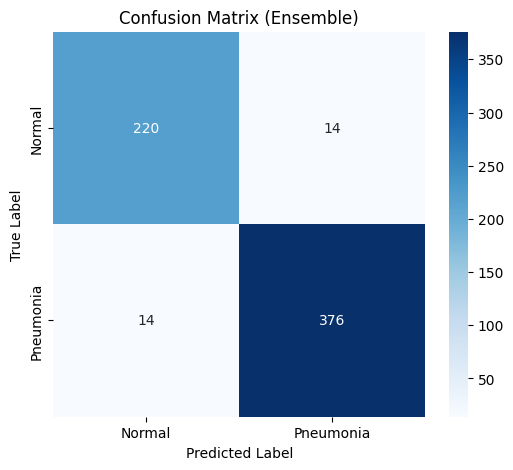

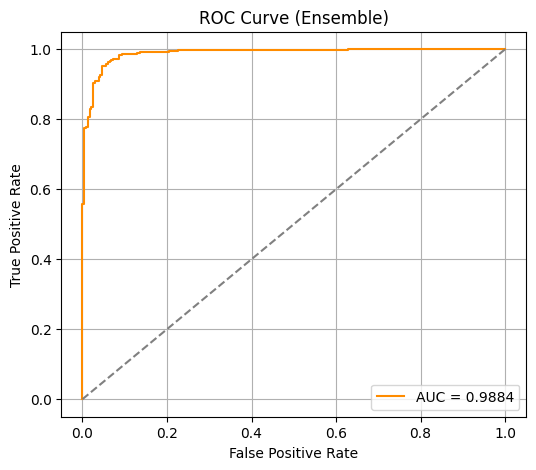

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prediksi akhir berdasarkan threshold terbaik
y_pred_opt = (ensemble_probs >= best_thresh).astype(int)

# Evaluasi metrik
accuracy = np.mean(y_pred_opt == y_true)
precision = precision_score(y_true, y_pred_opt)
recall = recall_score(y_true, y_pred_opt)
f1 = f1_score(y_true, y_pred_opt)
auc = roc_auc_score(y_true, ensemble_probs)
cm = confusion_matrix(y_true, y_pred_opt)

# === Print Hasil ===
print("=== Ensemble Evaluation with Optimized Threshold ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred_opt, target_names=['Normal', 'Pneumonia']))

print("Confusion Matrix:")
print(cm)

# === Visualisasi Confusion Matrix ===
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Ensemble)')
plt.show()

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_true, ensemble_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Ensemble)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Youden Index ke GoogLeNet
Untuk memastikan perbandingan adil antara model tunggal dan ensemble, saya menerapkan threshold optimization menggunakan Youden Index juga pada GoogLeNet.

In [ ]:
import torch.nn.functional as F
import numpy as np

def get_model_probs(model, dataloader):
    """
    Mengembalikan array (y_probs, y_true) untuk satu model saja.
    - model: misalnya googlenet yang sudah diload dan di-eval()
    - dataloader: test_loader kamu
    """
    all_probs = []
    all_labels = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)[:, 1]  # Prob kelas Pneumonia

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

In [ ]:
# Asumsikan googlenet sudah diload dan test_loader siap
model = googlenet
y_probs_googlenet, y_true = get_model_probs(model, test_loader)

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

def find_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thresh = 0.5
    best_j = -1

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        j = sensitivity + specificity - 1

        if j > best_j:
            best_j = j
            best_thresh = thresh

    return best_thresh

In [ ]:
best_thresh_googlenet = find_best_threshold(y_true, y_probs_googlenet)
print(f"Threshold optimasi GoogLeNet: {best_thresh_googlenet:.2f}")

Threshold optimasi GoogLeNet: 0.87


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Prediksi akhir dengan threshold optimasi
y_pred_googlenet_opt = (y_probs_googlenet >= best_thresh_googlenet).astype(int)

# Hitung metrik
acc = accuracy_score(y_true, y_pred_googlenet_opt)
prec = precision_score(y_true, y_pred_googlenet_opt)
rec = recall_score(y_true, y_pred_googlenet_opt)
f1 = f1_score(y_true, y_pred_googlenet_opt)
auc = roc_auc_score(y_true, y_probs_googlenet)

print("=== GoogLeNet Evaluation with Optimized Threshold ===")
print(f"Threshold optimal : {best_thresh_googlenet:.2f}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred_googlenet_opt, target_names=['Normal', 'Pneumonia']))

=== GoogLeNet Evaluation with Optimized Threshold ===
Threshold optimal : 0.87
Accuracy  : 0.9615
Precision : 0.9645
Recall    : 0.9744
F1-Score  : 0.9694
AUC       : 0.9904

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.94      0.95       234
   Pneumonia       0.96      0.97      0.97       390

    accuracy                           0.96       624
   macro avg       0.96      0.96      0.96       624
weighted avg       0.96      0.96      0.96       624



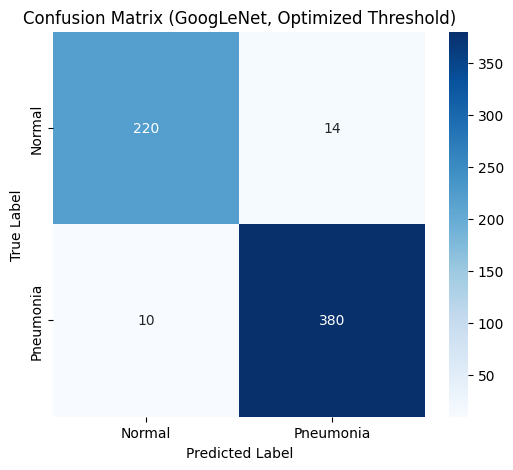

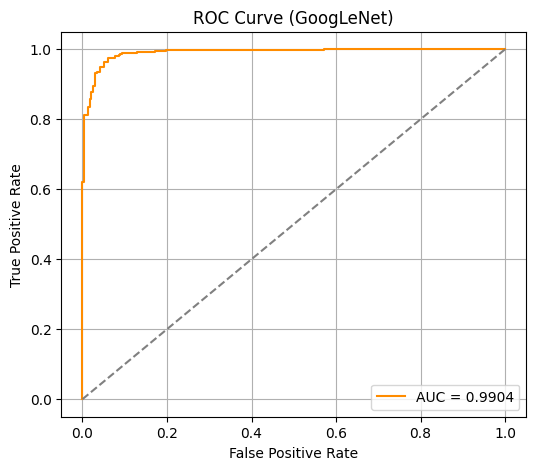

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_googlenet_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (GoogLeNet, Optimized Threshold)')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs_googlenet)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GoogLeNet)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()